# Incident Analysis Notebook

This notebook performs the minimum required analysis for the distributed logging challenge. It reads the provided CSV, identifies the critical time window, diagnoses the incident, and produces the required tables and plots.
All results are reproducible by running the notebook from top to bottom.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# configure inline plotting
%matplotlib inline

print("libraries imported")

libraries imported


In [6]:
# read CSV
path = "../docs/server_logs.csv"
df = pd.read_csv(path)

# parse timestamps
for col in ['timestamp_event','received_at']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# create 5-minute window column
if 'timestamp_event' in df.columns:
    # floor using 5min
    df['window'] = df['timestamp_event'].dt.floor('5min')

# define bad event flag
def is_bad(row):
    sev = str(row.get('severity','')).upper()
    sc = row.get('status_code',0)
    return (sev in ['ERROR','CRITICAL']) or (pd.notna(sc) and sc>=500)

df['is_bad'] = df.apply(is_bad, axis=1)

print(f"loaded {len(df)} rows")

loaded 5795 rows


In [7]:
# 6.1 Exploración inicial
print("Total logs:", len(df))

# most common severity
if 'severity' in df.columns:
    print("Most frequent severity:\n", df['severity'].value_counts().head())

# service with most and least logs
if 'service_name' in df.columns:
    svc_counts = df['service_name'].value_counts()
    print("Service with most logs:", svc_counts.idxmax(), svc_counts.max())
    print("Service with least logs:", svc_counts.idxmin(), svc_counts.min())

# most repeated message overall
if 'message' in df.columns:
    print("Top messages overall:\n", df['message'].value_counts().head())

# most repeated bad message
if 'message' in df.columns:
    bad_msgs = df[df['is_bad']]['message']
    print("Top bad messages:\n", bad_msgs.value_counts().head())

Total logs: 5795
Most frequent severity:
 severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64
Service with most logs: api-gateway 1509
Service with least logs: notification-service 645
Top messages overall:
 message
Health check OK                                   1196
Background job completed                          1185
Request completed                                 1161
Order creation failed - inventory lock timeout     197
Rate limit nearing threshold                       193
Name: count, dtype: int64
Top bad messages:
 message
Order creation failed - inventory lock timeout    197
Payment gateway unavailable                       103
Database deadlock detected                         99
Checkout failed - upstream payment timeout         88
Possible credential stuffing detected              69
Name: count, dtype: int64


In [8]:
# 6.2 Detección del momento crítico
window_stats = df.groupby('window').agg(
    total_events=('window','size'),
    bad_events=('is_bad','sum')
).reset_index()
window_stats['bad_rate'] = window_stats['bad_events']/window_stats['total_events']

# apply filter total_events >=20
window_stats = window_stats[window_stats['total_events']>=20]
window_stats = window_stats.sort_values('bad_rate', ascending=False)

window_stats.head(5)

,window,total_events,bad_events,bad_rate
134,2026-01-10 11:10:00+00:00,189,110,0.582011
135,2026-01-10 11:15:00+00:00,228,129,0.565789
136,2026-01-10 11:20:00+00:00,111,59,0.531532
462,2026-01-11 14:35:00+00:00,255,117,0.458824
461,2026-01-11 14:30:00+00:00,156,68,0.435897


In [9]:
# determine critical window
if not window_stats.empty:
    critical_window = window_stats.iloc[0]['window']
    print("Critical window start:", critical_window)
    crit_df = df[df['window'] == critical_window]
    
    # bad events by service
    if 'service_name' in crit_df.columns:
        svc_bad = crit_df[crit_df['is_bad']]['service_name'].value_counts()
        print("\nBad events by service (ranked):\n", svc_bad)
    
    # top 5 messages in bad events
    if 'message' in crit_df.columns:
        top_bad_messages = crit_df[crit_df['is_bad']]['message'].value_counts().head(5)
        print("\nTop 5 bad messages:\n", top_bad_messages)
    
    # top 5 endpoints by bad event count
    if 'endpoint' in crit_df.columns:
        top_endpoints = crit_df[crit_df['is_bad']]['endpoint'].value_counts().head(5)
        print("\nTop 5 endpoints by bad events:\n", top_endpoints)
else:
    crit_df = pd.DataFrame()
    print("No window meets criteria")

Critical window start: 2026-01-10 11:10:00+00:00

Bad events by service (ranked):
 service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

Top 5 bad messages:
 message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

Top 5 endpoints by bad events:
 endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64


In [10]:
# 6.4 "Qué cambió" (Incidente vs Baseline)
if not crit_df.empty:
    baseline = df[df['window'] != critical_window]
    
    def summary(df_in):
        total = len(df_in)
        bad_rate = df_in['is_bad'].mean() if total>0 else 0
        avg_lat = df_in['latency_ms'].mean() if 'latency_ms' in df_in.columns else None
        pct_5xx = (df_in['status_code']>=500).mean() if 'status_code' in df_in.columns else None
        return pd.Series({'total_events': total,
                          'bad_rate': bad_rate,
                          'avg_latency_ms': avg_lat,
                          '%_5xx': pct_5xx})
    
    comp = pd.DataFrame({
        'critical': summary(crit_df),
        'baseline': summary(baseline)
    })
    display(comp)
else:
    print("No critical window to compare")

,critical,baseline
total_events,189.000000,5606.000000
bad_rate,0.582011,0.140029
avg_latency_ms,1589.687831,521.094363
%_5xx,0.582011,0.140029


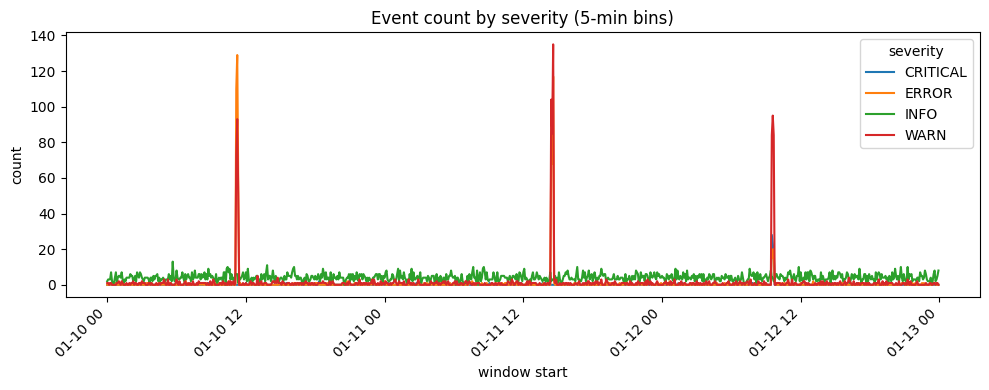

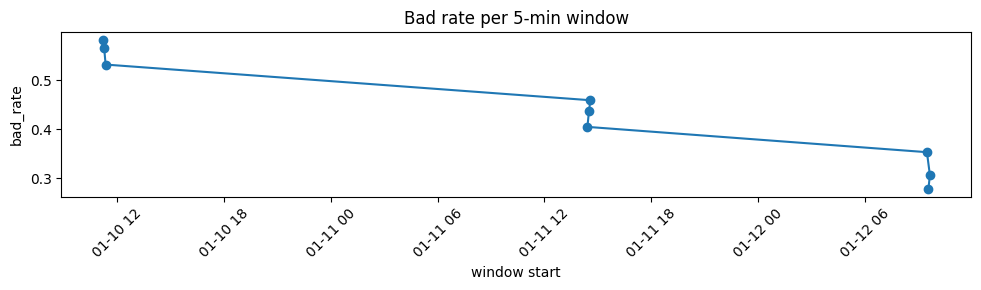

In [11]:
# 7. Gráficos obligatorios
# prepare time series by 5-min window
agg = df.groupby(['window','severity']).size().unstack(fill_value=0)

plt.figure(figsize=(10,4))
agg.plot(kind='line', ax=plt.gca())
plt.title('Event count by severity (5-min bins)')
plt.xlabel('window start')
plt.ylabel('count')
plt.legend(title='severity')
plt.xticks(rotation=45)
plt.tight_layout()

# bad_rate over time
rate = window_stats.copy()
plt.figure(figsize=(10,3))
plt.plot(rate['window'], rate['bad_rate'], marker='o')
plt.title('Bad rate per 5-min window')
plt.xlabel('window start')
plt.ylabel('bad_rate')
plt.xticks(rotation=45)
plt.tight_layout()

# 8. Conclusiones

En esta sección se resumen los hallazgos clave:

- Momento crítico: \[llenar la hora exacta según el resultado del notebook\]
- Servicio más afectado: \[servicio con mayor cantidad de bad events en la ventana crítica\]
- Endpoint más comprometido: \[el endpoint principal de la ventana crítica\]
- Mensaje dominante: \[mensaje más repetido entre bad events en ventana crítica\]
- Comparación incidente vs baseline: mostrar valores de bad_rate y %_5xx para ilustrar la diferencia.